In [2]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import json
import seaborn as sns
from dataclasses import dataclass, asdict
from ml_enhance import QuantumFPFileLoader, QuantumFPDatasetBuilder, ConformerAggregator

In [3]:
errors = pd.read_json("../data/QM9/error_batches.json")

with open("../data/QM9/qm9_test.json") as f:
    mapping = pd.DataFrame(json.load(f)["inputs"])

error_smiles = mapping[mapping["id"].isin(errors["Id"])]["smiles"].values

In [1]:
# from rdkit import Chem
# from rdkit.Chem import Draw
# from IPython.display import display

# for smiles in error_smiles:
#     mol = Chem.MolFromSmiles(smiles)
    
#     if mol is not None:
#         img = Draw.MolToImage(mol)
#         display(img)
#     else:
#         print(f"Invalid SMILES: {smiles}")

In [10]:
errors_noprot = pd.read_json("../data/QM9/error_batches_no_prot.json")

with open("../data/QM9/qm9_test.json") as f:
    mapping = pd.DataFrame(json.load(f)["inputs"])

error_noprot_smiles = mapping[mapping["id"].isin(errors_noprot["Id"])]["smiles"].values

In [4]:
# from rdkit import Chem
# from rdkit.Chem import Draw
# from IPython.display import display

# for smiles in error_noprot_smiles[::8]:
#     mol = Chem.MolFromSmiles(smiles)
    
#     if mol is not None:
#         img = Draw.MolToImage(mol)
#         display(img)
#     else:
#         print(f"Invalid SMILES: {smiles}")

## GFN2-xTB comparison to QM9 values

QM9 is a dataset consisting of about 130k molecules, for which QM properties are calculated on the DFT level of theory. Exact specifications of the level of theory are the following: **B3LYP/6-31G(2df,p)** (hybrid-GGA)

GFN2-xTB is a semi-empirical method that uses a parameterized density functional tight-binding method on the LDA level of theory using a minimal STO-nG basis set. This method also adds a correction to the electron density $\rho$ by accounting for up to the third order variation in the electron density $\delta \rho$.


Some of the molecular properties that are both present in the QM9 dataset and are generated by QuantumFP

|                          | QM9 unit |         QFP unit         |
|:------------------------:|:--------:|:------------------------:|
|   Dipole moment (norm)   |   Debye  |        $e$ $a_0$         |
| Isotropic polarizability |  $a_0^3$ | $e^2$ $a_0^2$ / hartree  |
|       HOMO-LUMO gap      |    eV    |          hartree         |
|     Zero point energy    |    eV    |          kcal/mol        |
|    Atomization energy    |    eV    |          hartree         |

In [2]:
@dataclass
class ConversionUnits:
    """Class containing conversion units from QM9 units to QFP units."""
    mu: float = 0.3934303 # Debye to e bohr
    alpha: float = 1.0
    gap: float = 0.0367493 # eV to hartree
    zpve: float = 23.0605 # eV to kcal/mol
    U0_atom: float = 0.0367493 # eV to hartree

conversion = asdict(ConversionUnits())

In [39]:
loader = QuantumFPFileLoader("../data/QM9/output")
files = loader.list_output_files()

In [64]:
wanted_properties = ["original_smiles", "output_smiles", "energy", "molecular_dipole_norm", "molecular_polarizability_mean", "homo_lumo_gap", "zero_point_energy", "atomization_energy"]

In [65]:
l = []
for file in tqdm(files):
    for df in loader.stream_conformer_dataframe(file):
        tdf = df.loc[df["energy"].argmin(), wanted_properties]
        l.append(tdf)

qfp_data = pd.DataFrame(l).reset_index(drop=True)

qfp_data = qfp_data.rename(columns={"original_smiles": "ref_smiles"})
qfp_data["molecular_polarizability_mean"] = abs(qfp_data["molecular_polarizability_mean"])
qfp_data.head()

100%|██████████| 994/994 [00:28<00:00, 34.45it/s]


,ref_smiles,output_smiles,energy,molecular_dipole_norm,molecular_polarizability_mean,homo_lumo_gap,zero_point_energy,atomization_energy
0,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...,-29.202215,1.118455,46.754075,0.320875,110.931789,4.360003
1,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...,-26.603291,1.952840,48.839043,0.174933,100.258934,3.710324
2,[c:1]1([H:9])[c:2]([H:10])[n:3]([H:11])[c:4]2[...,[c:1]1([H:9])[c:2]([H:10])[n:3]([H:11])[c:4]2[...,-21.447868,0.537530,55.082655,0.123321,75.193377,3.508721
3,[N:1]1([H:10])[C:2]([H:11])([H:12])[C@@:3]2([H...,[N+:1]1([H:10])([H:19])[C:2]([H:11])([H:12])[C...,-26.766716,2.365432,49.695413,0.123820,91.983999,3.453884
4,[C:1]([O:2][C@@:3]12[C:4]([H:13])([H:14])[N@@+...,[C:1]([O:2][C@@:3]12[C:4]([H:13])([H:14])[N@@+...,-27.600046,2.349558,49.816051,0.262380,112.712740,3.917480


In [69]:
qfp_data["check"] = qfp_data["ref_smiles"] == qfp_data["output_smiles"]
filtered_qfp_data = qfp_data[qfp_data["check"]]

For each molecule, we have loaded the minimal energy conformer and will compare its properties to the QM9. **This comparison does however come with an inconsistency in the fact that the molecular properties are calculated on different molecular geometries**.

Geometry optimization in QM9 consists of an initial relaxation using PM7 semi-empirical method, followed by a B3LYP relaxation. (see QM9 paper)

Geometry optimization in QuantumFP consists of an initial relaxation at the GFN-FF level of theory, followed by a GFN2-xTB minimization.

Despite this discrepancy, this comparison still provides a crude, general indication of how accurate QuantumFP features are compared to DFT level of theory.

In [70]:
name_map = {
    "U0_atom": "atomization_energy",
    "mu": "molecular_dipole_norm",
    "alpha": "molecular_polarizability_mean",
    "gap": "homo_lumo_gap",
    "zpve": "zero_point_energy"
}

In [73]:
qm9_data = pd.read_csv("qm9_values_of_mols.csv", index_col=0).rename(columns={"cleaned_smiles": "ref_smiles"})
qm9_data["U0_atom"] = abs(qm9_data["U0_atom"])
qm9_data.head()

,smiles,mu,alpha,gap,zpve,U0_atom,ref_smiles
87942,[H]O[C@@]1(C([H])([H])[H])C2(O[C@]1([H])C([H])...,2.3929,79.029999,7.948446,4.882349,85.460770,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...
70440,[H]O[C@@]12C([H])([H])[N@H+]3C([H])([H])[C@]1(...,1.8703,75.150002,6.114398,4.104865,77.043495,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...
121936,[H]C1=C([H])C(C([H])([H])C#CC([H])([H])[H])=NO1,3.1128,78.360001,6.628694,3.361558,71.956764,[c:1]1([H:10])[c:2]([H:11])[c:3]([C:4]([C:5]#[...
20499,[H]OC1=C([H])N([H])N=C1C([H])([H])C([H])([H])[H],0.5121,66.709999,6.413723,3.573453,67.314606,[O:1]([c:2]1[c:3]([H:10])[n:4]([H:11])[n:5][c:...
125881,[H]C(=O)C1=C([H])ON=C1N([H])C([H])([H])[H],2.7754,71.180000,4.892607,3.058206,65.635040,[C:1](=[O:2])([c:3]1[c:4]([H:11])[o:5][n:6][c:...


In [74]:
for col in qm9_data.columns: 
    if col in conversion.keys():
        qm9_data[f"{name_map[col]}_qm9"] = qm9_data[col] * conversion[col]
    else:
        print("not converted: ", col)

not converted:  smiles
not converted:  ref_smiles


In [75]:
conv_qm9_data = qm9_data.filter(regex="ref|qm9")
conv_qm9_data.head()

,ref_smiles,molecular_dipole_norm_qm9,molecular_polarizability_mean_qm9,homo_lumo_gap_qm9,zero_point_energy_qm9,atomization_energy_qm9
87942,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...,0.941439,79.029999,0.2921,112.589398,3.140623
70440,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...,0.735833,75.150002,0.2247,94.660230,2.831295
121936,[c:1]1([H:10])[c:2]([H:11])[c:3]([C:4]([C:5]#[...,1.224670,78.360001,0.2436,77.519218,2.644361
20499,[O:1]([c:2]1[c:3]([H:10])[n:4]([H:11])[n:5][c:...,0.201476,66.709999,0.2357,82.405623,2.473765
125881,[C:1](=[O:2])([c:3]1[c:4]([H:11])[o:5][n:6][c:...,1.091926,71.180000,0.1798,70.523761,2.412042


In [83]:
merged_df = pd.merge(filtered_qfp_data, conv_qm9_data, on="ref_smiles")
merged_df = merged_df.reindex(sorted(merged_df.columns), axis=1)
merged_df

,atomization_energy,atomization_energy_qm9,check,energy,homo_lumo_gap,homo_lumo_gap_qm9,molecular_dipole_norm,molecular_dipole_norm_qm9,molecular_polarizability_mean,molecular_polarizability_mean_qm9,output_smiles,ref_smiles,zero_point_energy,zero_point_energy_qm9
0,4.360003,3.140623,True,-29.202215,0.320875,0.2921,1.118455,0.941439,46.754075,79.029999,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...,110.931789,112.589398
1,3.710324,2.831295,True,-26.603291,0.174933,0.2247,1.952840,0.735833,48.839043,75.150002,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...,100.258934,94.660230
2,3.508721,2.555303,True,-21.447868,0.123321,0.1797,0.537530,0.573739,55.082655,75.080002,[c:1]1([H:9])[c:2]([H:10])[n:3]([H:11])[c:4]2[...,[c:1]1([H:9])[c:2]([H:10])[n:3]([H:11])[c:4]2[...,75.193377,76.779390
3,3.917480,2.981724,True,-27.600046,0.262380,0.2952,2.349558,0.510594,49.816051,79.190002,[C:1]([O:2][C@@:3]12[C:4]([H:13])([H:14])[N@@+...,[C:1]([O:2][C@@:3]12[C:4]([H:13])([H:14])[N@@+...,112.712740,106.830134
4,4.634866,3.377440,True,-30.266678,0.403175,0.3140,0.682145,0.499696,47.268224,80.989998,[O:1]([C@@:2]1([H:11])[C:3]([H:12])([H:13])[O:...,[O:1]([C@@:2]1([H:11])[C:3]([H:12])([H:13])[O:...,126.567618,129.092867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
774,2.793385,2.150503,True,-20.337732,0.177383,0.2350,1.902492,0.582513,45.528224,68.680000,[C:1](#[C:2][C@:3]12[C@@:4]3([H:10])[N@+:5]4([...,[C:1](#[C:2][C@:3]12[C@@:4]3([H:10])[N@+:5]4([...,66.720636,59.499074
775,3.908287,2.797230,True,-27.171300,0.144618,0.2273,0.690567,0.754993,48.514080,71.459999,[C:1]1([H:10])=[C:2]([H:11])[C@@:3]2([H:12])[O...,[C:1]1([H:10])=[C:2]([H:11])[C@@:3]2([H:12])[O...,84.543453,86.614948
776,3.948147,2.692136,True,-30.394935,0.152923,0.2539,0.500354,0.226734,44.007222,69.040001,[O:1]([C@:2]1([H:11])[C:3]([H:12])([H:13])/[N:...,[O:1]([C@:2]1([H:11])[C:3]([H:12])([H:13])/[N:...,89.783539,93.224491
777,4.200570,2.994192,True,-29.462647,0.187401,0.3051,1.086168,1.567780,46.464410,76.889999,[O:1]([C@:2]([C:3]([H:12])([H:13])[H:14])([C@:...,[O:1]([C@:2]([C:3]([H:12])([H:13])[H:14])([C@:...,102.893282,104.958268


In [97]:
dft_data = pd.read_json("../data/dft_results/run_dft_rerun_results.json")
dft_data = dft_data.rename({"total_energy_hartree": "energy_dft", "homo_lumo_gap_eV": "homo_lumo_gap_dft", "zpe_kcal_mol": "zero_point_energy_dft", "dipole_norm_debye": "molecular_dipole_norm_dft", "mean_polarizability_bohr3": "molecular_polarizability_mean_dft", "atomization_energy_kcal_mol": "atomization_energy_dft"}, axis=1)

qm9_mols_df = pd.read_json("qm9_mols.json")
dft_data["ref_smiles"] = dft_data["fold_id"].apply(lambda id: qm9_mols_df.loc[id, "output_smiles"])
dft_data["zero_point_energy_dft"] = dft_data["zero_point_energy_dft"].apply(lambda x: x * 627.509)

dft_data = dft_data.drop(["fold_id", "size", "spin"], axis=1)

dft_data.head()

,energy_dft,homo_lumo_gap_dft,zero_point_energy_dft,molecular_dipole_norm_dft,molecular_polarizability_mean_dft,atomization_energy_dft,ref_smiles
0,-424.369538,0.288924,112.794416,0.835449,77.939877,3.330387,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...
1,-381.325499,0.242687,95.230722,3.327710,72.513456,2.742583,[C:1]1([H:10])=[C:2]([H:11])[C@:3]2([H:12])[N+...
2,-399.512455,0.220236,107.626898,0.800330,85.201767,3.191076,[c:1]1([H:10])[c:2]([N:3]([C:4]([H:12])([H:13]...
3,-423.096627,0.285674,97.099911,0.721329,77.076702,3.058021,[C:1](#[C:2][C@:3]([O:4][C:5]([H:12])([H:13])[...
4,-442.014682,0.303273,130.329631,0.712293,75.323637,3.237068,[O:1]([C:2]([C@:3]([O:4][H:14])([C@@:5]1([H:15...


In [99]:
merged2_df = pd.merge(merged_df, dft_data, on="ref_smiles")
merged2_df = merged2_df.reindex(sorted(merged2_df.columns), axis=1)
merged2_df

,atomization_energy,atomization_energy_dft,atomization_energy_qm9,check,energy,energy_dft,homo_lumo_gap,homo_lumo_gap_dft,homo_lumo_gap_qm9,molecular_dipole_norm,molecular_dipole_norm_dft,molecular_dipole_norm_qm9,molecular_polarizability_mean,molecular_polarizability_mean_dft,molecular_polarizability_mean_qm9,output_smiles,ref_smiles,zero_point_energy,zero_point_energy_dft,zero_point_energy_qm9
0,4.360003,3.330387,3.140623,True,-29.202215,-424.369538,0.320875,0.288924,0.2921,1.118455,0.835449,0.941439,46.754075,77.939877,79.029999,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...,[O:1]([C@@:2]1([C:3]([H:11])([H:12])[H:13])[C:...,110.931789,112.794416,112.589398
1,3.710324,2.876647,2.831295,True,-26.603291,-402.437544,0.174933,0.247382,0.2247,1.952840,1.510510,0.735833,48.839043,70.680486,75.150002,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...,[O:1]([C@@:2]12[C:3]([H:11])([H:12])[N@@+:4]3(...,100.258934,104.631440,94.660230
2,3.508721,2.685337,2.555303,True,-21.447868,-325.684831,0.123321,0.178655,0.1797,0.537530,0.585750,0.573739,55.082655,74.701664,75.080002,[c:1]1([H:9])[c:2]([H:10])[n:3]([H:11])[c:4]2[...,[c:1]1([H:9])[c:2]([H:10])[n:3]([H:11])[c:4]2[...,75.193377,77.454981,76.779390
3,3.917480,3.048400,2.981724,True,-27.600046,-403.609843,0.262380,0.274559,0.2952,2.349558,1.906108,0.510594,49.816051,75.583334,79.190002,[C:1]([O:2][C@@:3]12[C:4]([H:13])([H:14])[N@@+...,[C:1]([O:2][C@@:3]12[C:4]([H:13])([H:14])[N@@+...,112.712740,116.315238,106.830134
4,4.634866,3.590021,3.377440,True,-30.266678,-425.629718,0.403175,0.308941,0.3140,0.682145,0.650017,0.499696,47.268224,80.042590,80.989998,[O:1]([C@@:2]1([H:11])[C:3]([H:12])([H:13])[O:...,[O:1]([C@@:2]1([H:11])[C:3]([H:12])([H:13])[O:...,126.567618,129.264314,129.092867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761,2.793385,2.115511,2.150503,True,-20.337732,-324.614733,0.177383,0.242463,0.2350,1.902492,1.720290,0.582513,45.528224,64.482005,68.680000,[C:1](#[C:2][C@:3]12[C@@:4]3([H:10])[N@+:5]4([...,[C:1](#[C:2][C@:3]12[C@@:4]3([H:10])[N@+:5]4([...,66.720636,68.519969,59.499074
762,3.908287,2.944406,2.797230,True,-27.171300,-421.982466,0.144618,0.229690,0.2273,0.690567,0.700681,0.754993,48.514080,70.366471,71.459999,[C:1]1([H:10])=[C:2]([H:11])[C@@:3]2([H:12])[O...,[C:1]1([H:10])=[C:2]([H:11])[C@@:3]2([H:12])[O...,84.543453,87.306130,86.614948
763,3.948147,2.845725,2.692136,True,-30.394935,-476.337600,0.152923,0.258477,0.2539,0.500354,0.395533,0.226734,44.007222,68.240085,69.040001,[O:1]([C@:2]1([H:11])[C:3]([H:12])([H:13])/[N:...,[O:1]([C@:2]1([H:11])[C:3]([H:12])([H:13])/[N:...,89.783539,93.672419,93.224491
764,4.200570,3.169416,2.994192,True,-29.462647,-440.446211,0.187401,0.292048,0.3051,1.086168,1.142085,1.567780,46.464410,75.240235,76.889999,[O:1]([C@:2]([C:3]([H:12])([H:13])[H:14])([C@:...,[O:1]([C@:2]([C:3]([H:12])([H:13])[H:14])([C@:...,102.893282,105.389487,104.958268


In [102]:
suffix = "_qm9"

nmae_results = {}

for col in merged2_df.columns:
    if col.endswith(suffix):
        base = col.replace(suffix, "")
        if base in merged2_df.columns:
            y_true = merged2_df[col]
            y_pred = merged2_df[base]

            mae = (y_true - y_pred).abs().mean()
            std = np.std(y_true)

            nmae = mae / std
            nmae_results[base] = nmae

nmae_series = pd.Series(nmae_results).sort_values()
print(nmae_series)

zero_point_energy                0.133345
molecular_dipole_norm            0.680780
homo_lumo_gap                    1.533694
atomization_energy               3.049806
molecular_polarizability_mean    3.213464
dtype: float64


In [103]:
suffix = "_dft"

nmae_results = {}

for col in merged2_df.columns:
    if col.endswith(suffix):
        base = col.replace(suffix, "")
        if base in merged2_df.columns:
            y_true = merged2_df[col]
            y_pred = merged2_df[base]

            mae = (y_true - y_pred).abs().mean()
            std = np.std(y_true)

            nmae = mae / std
            nmae_results[base] = nmae

nmae_series = pd.Series(nmae_results).sort_values()
print(nmae_series)

zero_point_energy                0.124496
molecular_dipole_norm            0.255668
homo_lumo_gap                    1.560791
atomization_energy               2.449401
molecular_polarizability_mean    3.001970
energy                           9.312594
dtype: float64


|nMAE | Meaning |
|-----|--------------- |
|~0.1 | excellent |
|~0.2–0.5 | good/moderate |
|~1.0 | error comparable to dataset variability |
|>1.0 | poor / uninformative model |

In [130]:
def plot(col: str, comp1: str, comp2: str) -> None:
    ax = sns.scatterplot(
        data=merged2_df,
        x=f"{col}{comp1}",
        y=f"{col}{comp2}",
    )

    # Get limits
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # Use the same range for both axes
    lims = [
        min(xmin, ymin),
        max(xmax, ymax)
    ]

    # Plot diagonal line
    ax.plot(lims, lims, color='gray')

    # Set limits so line is perfectly diagonal
    ax.set_xlim(lims)
    ax.set_ylim(lims)

In [118]:
import pandas as pd

df = merged2_df.drop(["ref_smiles", "energy"], axis=1)

pairs = {}
for col in df.columns:
    if col.endswith("_qm9"):
        base = col.replace("_qm9", "")
        if base in df.columns:
            pairs[base] = df[base].corr(df[col])

corr_series = pd.Series(pairs)
print(corr_series)

print("\n")

pairs = {}
for col in df.columns:
    if col.endswith("_dft"):
        base = col.replace("_dft", "")
        if base in df.columns:
            pairs[base] = df[base].corr(df[col])

corr_series = pd.Series(pairs)
print(corr_series)

atomization_energy               0.957541
homo_lumo_gap                    0.882785
molecular_dipole_norm            0.609419
molecular_polarizability_mean    0.814715
zero_point_energy                0.987175
dtype: float64


atomization_energy               0.974636
homo_lumo_gap                    0.878510
molecular_dipole_norm            0.985546
molecular_polarizability_mean    0.815599
zero_point_energy                0.999483
dtype: float64


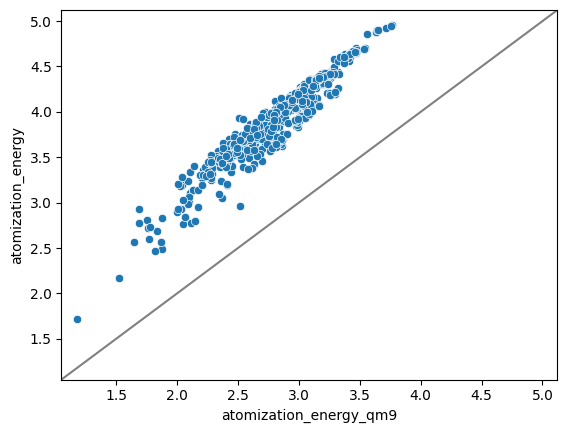

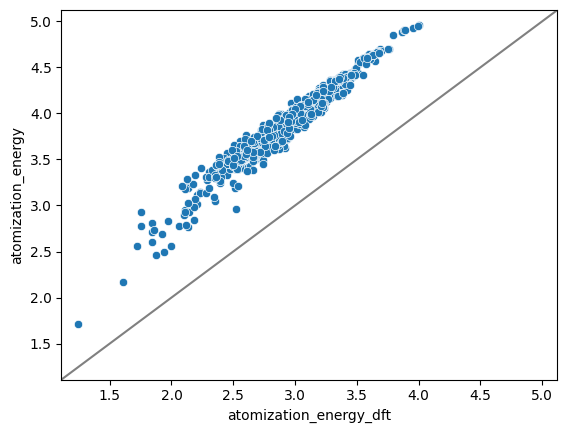

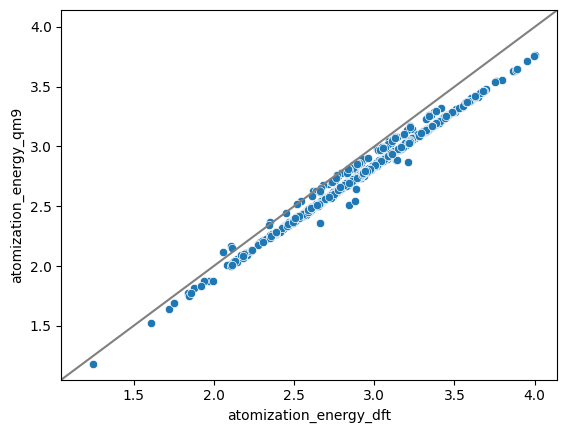

In [132]:
plot("atomization_energy", "_qm9", "")
plt.show()
plot("atomization_energy", "_dft", "")
plt.show()
plot("atomization_energy", "_dft", "_qm9")
plt.show()

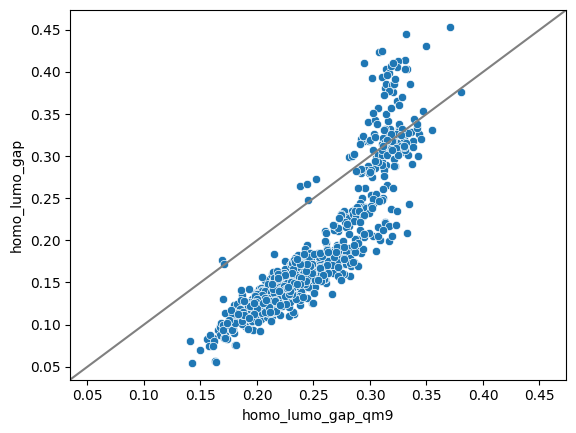

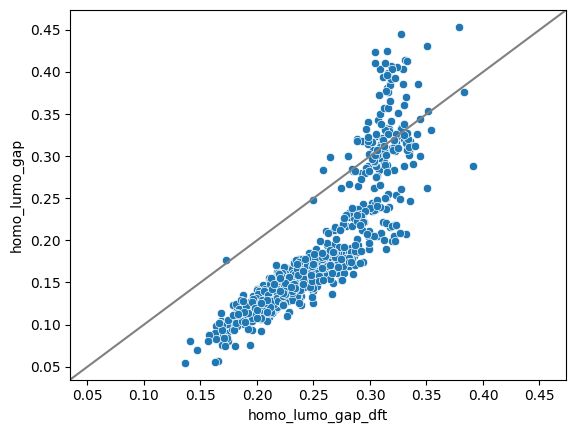

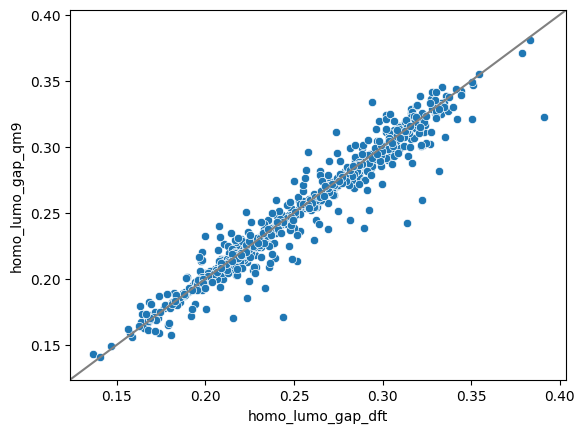

In [133]:
plot("homo_lumo_gap", "_qm9", "")
plt.show()
plot("homo_lumo_gap", "_dft", "")
plt.show()
plot("homo_lumo_gap", "_dft", "_qm9")
plt.show()

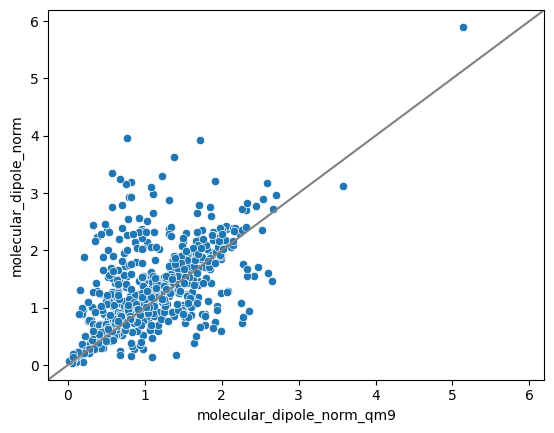

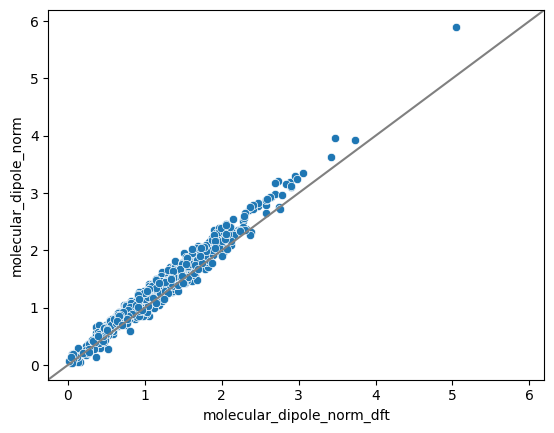

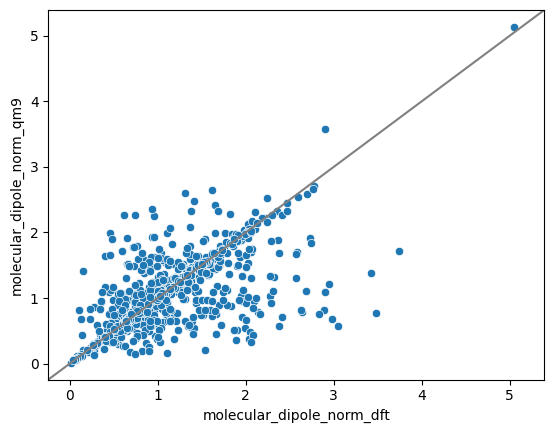

In [134]:
plot("molecular_dipole_norm", "_qm9", "")
plt.show()
plot("molecular_dipole_norm", "_dft", "")
plt.show()
plot("molecular_dipole_norm", "_dft", "_qm9")
plt.show()

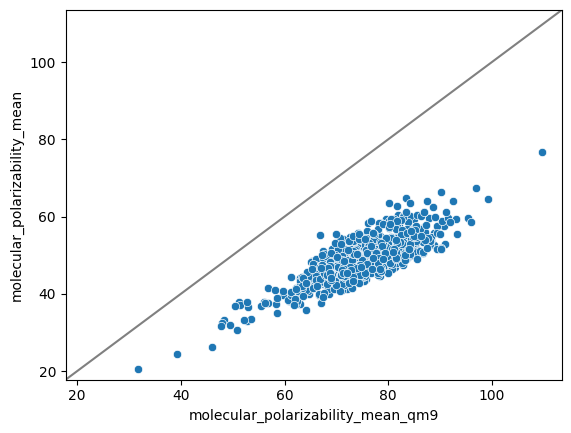

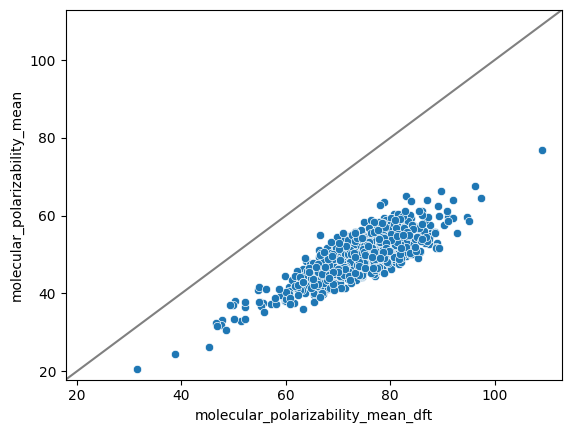

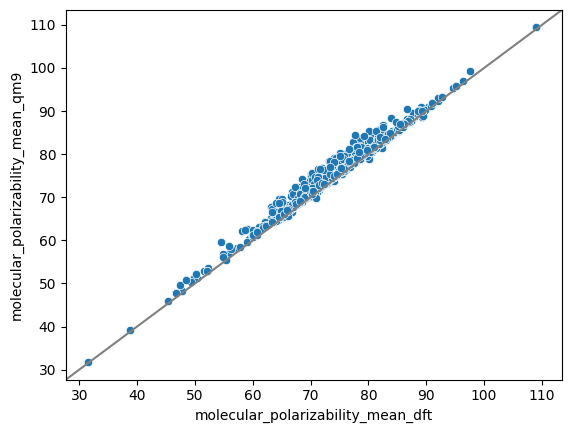

In [135]:
plot("molecular_polarizability_mean", "_qm9", "")
plt.show()
plot("molecular_polarizability_mean", "_dft", "")
plt.show()
plot("molecular_polarizability_mean", "_dft", "_qm9")
plt.show()

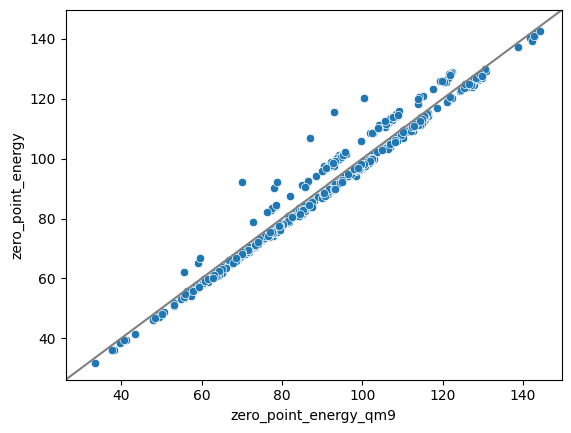

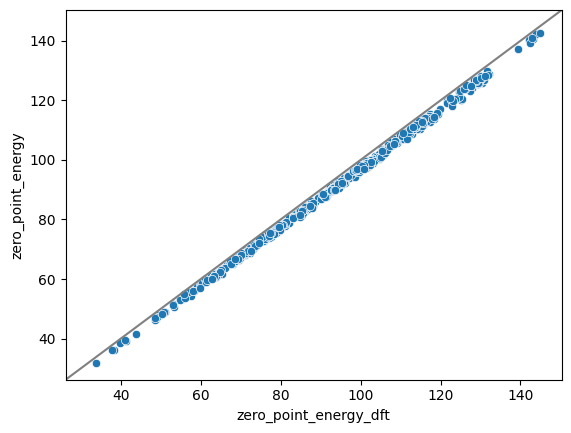

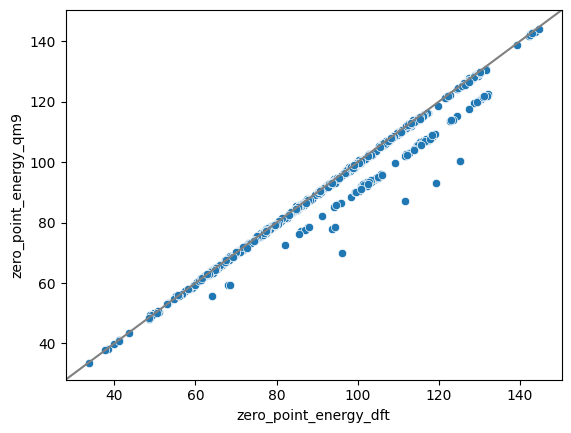

In [136]:
plot("zero_point_energy", "_qm9", "")
plt.show()
plot("zero_point_energy", "_dft", "")
plt.show()
plot("zero_point_energy", "_dft", "_qm9")
plt.show()

There seems to be quite a poor correspondence between QM9 values and the GFN2-xTB values. Despite this, atomization energy and zero point energy do show a strong correlation meaning the information is still valuable.

**Better approach is**: use the optimized structures from GFN2 and run DFT calculations on them.